<a href="https://colab.research.google.com/github/04suman/sumanamit/blob/main/Copy_of_KOA_VGG_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import PIL
import cv2
import tensorflow as tf
from tensorflow import keras

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os


In [ ]:
good=os.listdir("/content/drive/MyDrive/mydata/train/0/")

In [ ]:
b4=os.listdir("/content/drive/MyDrive/mydata/train/3/")


In [ ]:
bad=b4[:1000]

In [ ]:
x1=[]
y1=[]
for i in good[:800]:
    x=cv2.imread(str("/content/drive/MyDrive/mydata/train/0/"+i))
    x1.append(x)
    y1.append(1)


In [ ]:
print(x1[1])

[[[135 135 135]
  [134 134 134]
  [135 135 135]
  ...
  [180 180 180]
  [179 179 179]
  [176 176 176]]

 [[135 135 135]
  [135 135 135]
  [135 135 135]
  ...
  [180 180 180]
  [179 179 179]
  [176 176 176]]

 [[135 135 135]
  [136 136 136]
  [136 136 136]
  ...
  [179 179 179]
  [178 178 178]
  [177 177 177]]

 ...

 [[ 67  67  67]
  [ 68  68  68]
  [ 69  69  69]
  ...
  [170 170 170]
  [168 168 168]
  [164 164 164]]

 [[ 66  66  66]
  [ 67  67  67]
  [ 70  70  70]
  ...
  [168 168 168]
  [166 166 166]
  [164 164 164]]

 [[ 67  67  67]
  [ 68  68  68]
  [ 71  71  71]
  ...
  [168 168 168]
  [166 166 166]
  [163 163 163]]]


In [ ]:
x2=[]
y2=[]
for i in bad[:800]:
    x=cv2.imread(str("/content/drive/MyDrive/mydata/train/3/"+i))
    x2.append(x)
    y2.append(0)

xdata=x1+x2
ydata=y1+y2

In [ ]:
xdata=np.array(xdata)
ydata=np.array(ydata)
xdata=xdata/255
ydata

array([1, 1, 1, ..., 0, 0, 0])

In [ ]:
# prompt: vgg16_weight_path = '../input/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5' base_model = tf.keras.applications.VGG16(     weights=vgg16_weight_path,     include_top=False,     input_shape=IMG_SIZE + (3,) )  model = tf.keras.models.Sequential() model.add(base_model) model.add(tf.keras.layers.Flatten()) model.add(tf.keras.layers.Dropout(0.5)) model.add(tf.keras.layers.Dense(1, activation='sigmoid'))  model.layers[0].trainable = False  model.compile(     loss='binary_crossentropy',     optimizer=tf.keras.optimizers.Adam(),     metrics=['accuracy'] )  model  .summary()
IMG_SIZE=(224,224,)
vgg16_weight_path = '../input/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5'
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)
model = tf.keras.models.Sequential()
model.add(base_model)
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model.layers[0].trainable = False
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


ValueError: Undefined shapes are not supported.

In [ ]:
# prompt: vgg16_weight_path = '../input/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5' base_model = tf.keras.applications.VGG16(     weights=vgg16_weight_path,     include_top=False,     input_shape=IMG_SIZE + (3,) )  model = tf.keras.models.Sequential() model.add(base_model) model.add(tf.keras.layers.Flatten()) model.add(tf.keras.layers.Dropout(0.5)) model.add(tf.keras.layers.Dense(1, activation='sigmoid'))  model.layers[0].trainable = False  model.compile(     loss='binary_crossentropy',     optimizer=tf.keras.optimizers.Adam(),     metrics=['accuracy'] )  model  .summary()
IMG_SIZE=(224,224,)
vgg16_weight_path = '../input/vgg16/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5'
base_model = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

# Build the model with an Input layer to define input shape explicitly
input_tensor = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(input_tensor)  # Pass the input tensor to the base model
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dropout(0.5)(x)
output_tensor = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=input_tensor, outputs=output_tensor) # Create the Model using the Functional API

model.layers[1].trainable = False # Freeze the VGG16 layers (now at index 1)

model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │          25,089 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,739,777 (56.23 MB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(xdata,ydata,test_size=0.2,random_state=43)

In [ ]:
model.evaluate(xtest,ytest)

10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.4982 - loss: 0.7213


[0.7282524704933167, 0.48076921701431274]

In [ ]:
history=model.fit(xtrain,ytrain,epochs=50)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 476ms/step - accuracy: 0.5433 - loss: 0.7515
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.7321 - loss: 0.5453
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.7602 - loss: 0.4833
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 131ms/step - accuracy: 0.8235 - loss: 0.4251
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 125ms/step - accuracy: 0.8340 - loss: 0.3786
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.8517 - loss: 0.3594
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.8422 - loss: 0.3518
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.8682 - loss: 0.3213
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.8927 - loss: 0.2877
Epoch 10/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.8735 - loss: 0.2958
Epoch 11/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.8848 - loss: 0.2768
Epoch 12/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/s

In [ ]:
history=model.fit(xtrain,ytrain,epochs=30)

Epoch 1/30
39/39 [==============================] - 5s 128ms/step - loss: 0.1742 - accuracy: 0.9269
Epoch 2/30
39/39 [==============================] - 5s 131ms/step - loss: 0.1604 - accuracy: 0.9398
Epoch 3/30
39/39 [==============================] - 5s 132ms/step - loss: 0.1513 - accuracy: 0.9454
Epoch 4/30
39/39 [==============================] - 5s 134ms/step - loss: 0.1639 - accuracy: 0.9373
Epoch 5/30
39/39 [==============================] - 5s 136ms/step - loss: 0.1567 - accuracy: 0.9454
Epoch 6/30
39/39 [==============================] - 5s 135ms/step - loss: 0.1520 - accuracy: 0.9365
Epoch 7/30
39/39 [==============================] - 5s 136ms/step - loss: 0.1837 - accuracy: 0.9293
Epoch 8/30
39/39 [==============================] - 5s 132ms/step - loss: 0.1751 - accuracy: 0.9333
Epoch 9/30
39/39 [==============================] - 5s 133ms/step - loss: 0.1500 - accuracy: 0.9398
Epoch 10/30
39/39 [==============================] - 5s 133ms/step - loss: 0.1592 - accuracy: 0.9438

In [ ]:
model.evaluate(xtest,ytest)

10/10 [==============================] - 1s 122ms/step - loss: 0.2440 - accuracy: 0.9006


[0.243988499045372, 0.9006410241127014]

In [ ]:
model.evaluate(xtest,ytest)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.8960 - loss: 0.2492


[0.2644629180431366, 0.8878205418586731]

In [ ]:
model.evaluate(xtest,ytest)


10/10 [==============================] - 1s 122ms/step - loss: 0.2410 - accuracy: 0.9006


[0.2410435825586319, 0.9006410241127014]

In [ ]:
model.evaluate(xtest,ytest)

10/10 [==============================] - 7s 720ms/step - loss: 0.2560 - accuracy: 0.8910


[0.25603780150413513, 0.8910256624221802]

In [ ]:
from sklearn.metrics import precision_score, \
    recall_score, confusion_matrix, classification_report, \
    accuracy_score, f1_score

In [ ]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

actual = numpy.random.binomial(1,.9,size = 1000)
predicted = numpy.random.binomial(1,.9,size = 1000)

confusion_matrix = metrics.confusion_matrix(xtest, ypred)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()

ValueError: Classification metrics can't handle a mix of unknown and continuous targets

In [ ]:
from sklearn.metrics import confusion_matrix

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [ ]:
ypred=model.predict(xtest)
yp=[1 if x>0.5 else 0 for x in ypred]

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step


In [ ]:
cm = confusion_matrix(ytest, yp)
cm

NameError: name 'confusion_matrix' is not defined

In [ ]:
from sklearn.metrics import confusion_matrix # Make sure confusion_matrix is imported in this cell's scope

# ... other code ... #

# Assuming 'ytest' is defined and available
cm = confusion_matrix(ytest, yp)
cm

array([[123,  28],
       [  7, 154]])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(ytest,yp)*100

88.78205128205127

In [ ]:
accuracy_score(ytest,yp)*100

90.06410256410257

In [ ]:
yp[:5]

[0, 0, 0, 1, 0]

In [ ]:
import seaborn as sns
sns.heatmap(cm_matrix, annot=True)

NameError: name 'cm_matrix' is not defined

<Axes: >

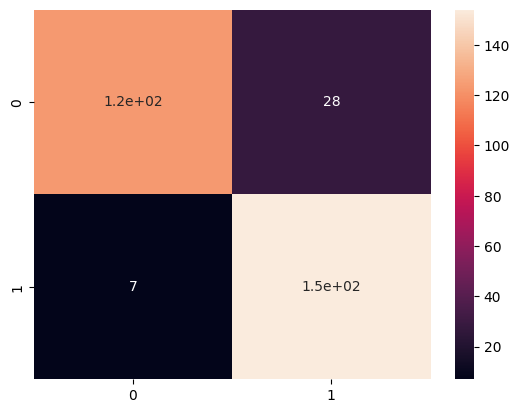

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming 'ytest' and 'yp' are your true and predicted labels respectively
cm_matrix = confusion_matrix(ytest, yp)  # Calculate the confusion matrix

sns.heatmap(cm_matrix, annot=True) # Now cm_matrix is defined and can be used

In [ ]:
print ('F1 score:', f1_score(ytest, yp)*100)
print ('Recall:', recall_score(ytest, yp)*100)
print ('Precision:', precision_score(ytest, yp)*100)
print ('\n clasification report:\n', classification_report(ytest, yp)*100)
print ('\n confussion matrix:\n',confusion_matrix(ytest, yp)*100)

NameError: name 'f1_score' is not defined

In [ ]:
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report, confusion_matrix

print ('F1 score:', f1_score(ytest, yp)*100)
print ('Recall:', recall_score(ytest, yp)*100)
print ('Precision:', precision_score(ytest, yp)*100)
print ('\n clasification report:\n', classification_report(ytest, yp)) # Removed *100 as it's not applicable to classification_report
print ('\n confussion matrix:\n',confusion_matrix(ytest, yp)) # Removed *100 as it's not applicable to confusion_matrix

F1 score: 89.79591836734694
Recall: 95.65217391304348
Precision: 84.61538461538461

 clasification report:
               precision    recall  f1-score   support

           0       0.95      0.81      0.88       151
           1       0.85      0.96      0.90       161

    accuracy                           0.89       312
   macro avg       0.90      0.89      0.89       312
weighted avg       0.89      0.89      0.89       312


 confussion matrix:
 [[123  28]
 [  7 154]]


In [ ]:
print ('F1 score:', f1_score(ytest, yp)*100)
print ('Recall:', recall_score(ytest, yp)*100)
print ('Precision:', precision_score(ytest, yp)*100)
print ('\n clasification report:\n', classification_report(ytest, yp)*100)
print ('\n confussion matrix:\n',confusion_matrix(ytest, yp)*100)

F1 score: 90.22082018927445
Recall: 88.81987577639751
Precision: 91.66666666666666

 clasification report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.90       151
           1       0.92      0.89      0.90       161

    accuracy                           0.90       312
   macro avg       0.90      0.90      0.90       312
weighted avg       0.90      0.90      0.90       312
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       151
           1       0.92      0.89      0.90       161

    accuracy                           0.90       312
   macro avg       0.90      0.90      0.90       312
weighted avg       0.90      0.90      0.90       312
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       151
           1       0.92      0.89      0.90       161

    accuracy                           0.90       312
   macro avg       0.9

In [ ]:
(11700+15300)/(3400+800+11700+15300)

In [ ]:
loss_list=history.history['loss']
acc_list=history.history['accuracy']

epoch_list=[i for i in range(30)]

In [ ]:
import matplotlib.pyplot as plt

NameError: name 'epoch_list' is not defined

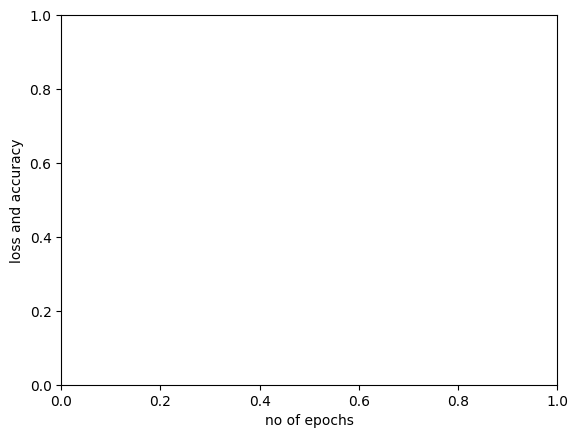

In [ ]:
import matplotlib.pyplot as plt
plt.ylabel('loss and accuracy')
plt.xlabel('no of epochs')
plt.plot(epoch_list,loss_list)
plt.plot(epoch_list,acc_list)
plt.legend(['loss','accuracy'],loc='center right')

plt.show()


NameError: name 'epoch_list' is not defined

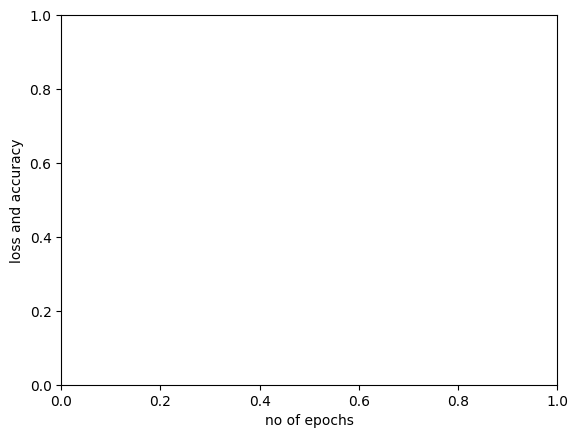

In [ ]:
import matplotlib.pyplot as plt

plt.ylabel('loss and accuracy')
plt.xlabel('no of epochs')
plt.plot(50, 50)
plt.plot(epoch_list, acc_list)
plt.legend(['loss', 'accuracy'], loc='center right')

plt.show()

In [ ]:
import matplotlib.pyplot as plt

# Define epoch_list, loss_list, and acc_list before using them
epoch_list = [i for i in range(30)]  # Or adjust the range if needed
loss_list = history.history['loss']   # Assuming 'history' is available
acc_list = history.history['accuracy'] # Assuming 'history' is available

plt.ylabel('loss and accuracy')
plt.xlabel('no of epochs')
plt.plot(epoch_list, loss_list)
plt.plot(epoch_list, acc_list)
plt.legend(['loss', 'accuracy'], loc='center right')

plt.show()

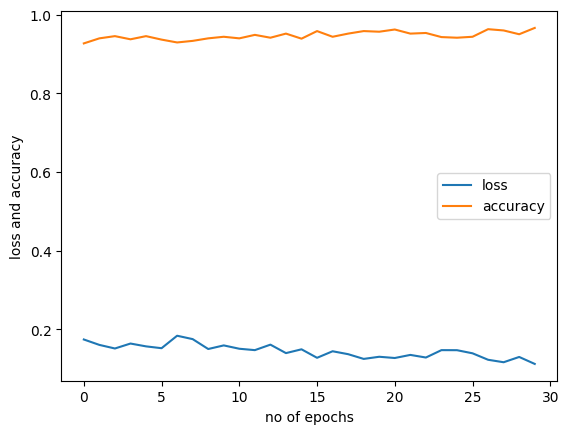

In [ ]:
plt.ylabel('loss and accuracy')
plt.xlabel('no of epochs')
plt.plot(epoch_list,loss_list)
plt.plot(epoch_list,acc_list)
plt.legend(['loss','accuracy'],loc='center right')

plt.show()


In [ ]:
'''IMG_SIZE=(224,224,)
vgg16_weight_path = '../input/vgg19/vgg19_weights_tf_dim_ordering_tf_kernels_notop.h5'
base_model = tf.keras.applications.VGG19(
    weights='imagenet',
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)
model19 = tf.keras.models.Sequential()
model19.add(base_model)
model19.add(tf.keras.layers.Flatten())
model19.add(tf.keras.layers.Dropout(0.5))
model19.add(tf.keras.layers.Dense(1, activation='sigmoid'))
model19.layers[0].trainable = False
model19.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)
model19.summary()

In [ ]:
history19=model19.fit(xtrain,ytrain,epochs=10)